In [108]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import datetime
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-crunch-round-1/sample_submission.csv
/kaggle/input/data-crunch-round-1/train.csv
/kaggle/input/data-crunch-round-1/test.csv


In [116]:
df_orig = pd.read_csv("/kaggle/input/data-crunch-round-1/train.csv")
df_orig['Date'] = df_orig.apply(lambda row: datetime(year=2018+row['Year'], 
                                                     month=row['Month'], 
                                                     day=row['Day']), axis=1)

df_orig['WindVX'] = df_orig['Wind_Speed'] * np.cos(np.radians(df_orig['Wind_Direction']))
df_orig['WindVY'] = df_orig['Wind_Speed'] * np.sin(np.radians(df_orig['Wind_Direction']))

cdate = ['Year', 'Month', 'Day']
cloc = ['latitude', 'longitude']
ck = ['kingdom']
ctarget = ['Avg_Temperature', 'Radiation', 'Rain_Amount', 'WindVX', 'WindVY']
cdrop = ['Avg_Feels_Like_Temperature', 'Temperature_Range', 'Feels_Like_Temperature_Range', 'Rain_Duration', 'Evapotranspiration', 'Wind_Speed', 'Wind_Direction']
kingdoms = df_orig["kingdom"].unique().tolist()
K_kingdoms = df_orig[df_orig['Avg_Temperature']>200]["kingdom"].unique().tolist()

df_orig['Avg_Temperature'] = df_orig['Avg_Temperature'].apply(lambda x: x - 273.15 if x > 200 else x)

df_orig.drop(columns=cdrop, inplace=True)

print(df_orig.columns)

df_orig

Index(['ID', 'Year', 'Month', 'Day', 'kingdom', 'latitude', 'longitude',
       'Avg_Temperature', 'Radiation', 'Rain_Amount', 'Date', 'WindVX',
       'WindVY'],
      dtype='object')


NameError: name 'df' is not defined

In [110]:
kingdoms, K_kingdoms

(['Arcadia',
  'Atlantis',
  'Avalon',
  'Camelot',
  'Dorne',
  'Eden',
  'El Dorado',
  'Elysium',
  'Emerald City',
  'Helios',
  'Krypton',
  'Metropolis',
  'Midgar',
  'Midgard',
  'Mordor',
  'Neo-City',
  'Neo-Tokyo',
  'Nirvana',
  'Olympus',
  'Pandora',
  'Rapture',
  'Rivendell',
  'Serenity',
  'Shangri-La',
  'Solara',
  'Solstice',
  'Sunspear',
  'Utopia',
  'Valyria',
  'Winterfell'],
 ['Atlantis',
  'El Dorado',
  'Emerald City',
  'Krypton',
  'Nirvana',
  'Olympus',
  'Pandora',
  'Rapture',
  'Rivendell',
  'Serenity',
  'Solara',
  'Utopia'])

In [111]:
df_orig.isna().sum()

ID                 0
Year               0
Month              0
Day                0
kingdom            0
latitude           0
longitude          0
Avg_Temperature    0
Radiation          0
Rain_Amount        0
Date               0
WindVX             0
WindVY             0
dtype: int64

In [112]:
df_orig.columns

Index(['ID', 'Year', 'Month', 'Day', 'kingdom', 'latitude', 'longitude',
       'Avg_Temperature', 'Radiation', 'Rain_Amount', 'Date', 'WindVX',
       'WindVY'],
      dtype='object')

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

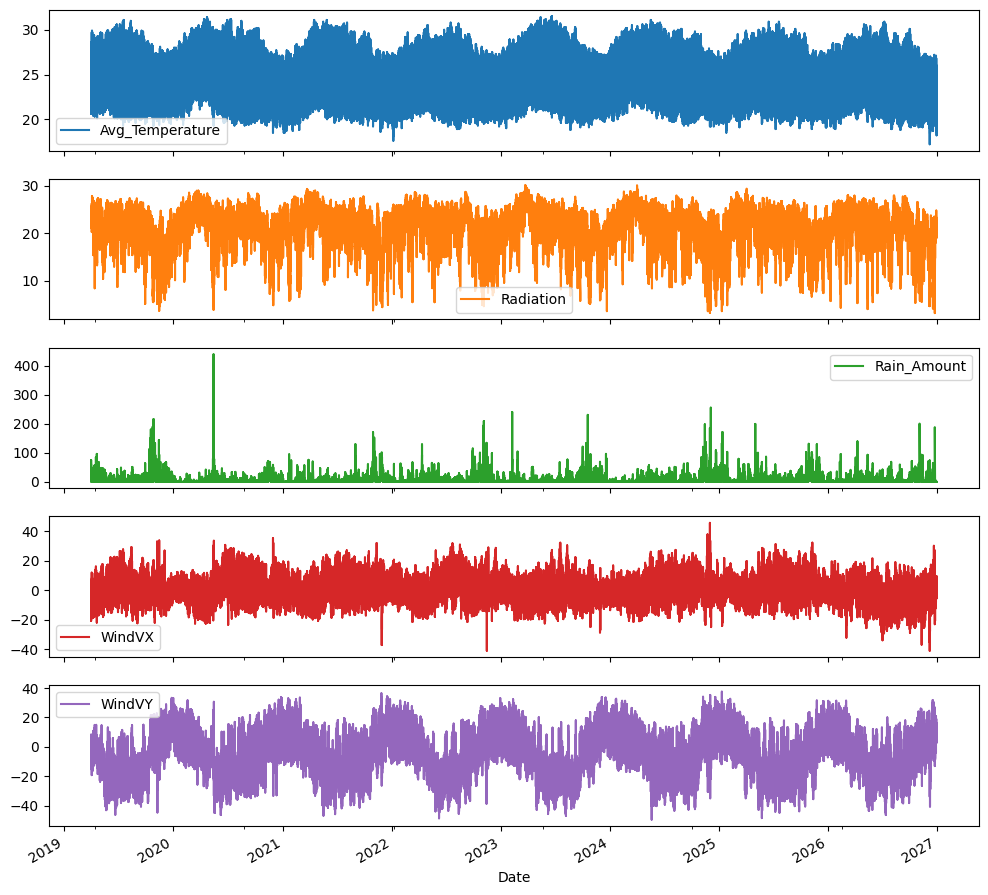

In [113]:
df_plot = df_orig[ctarget+['Date']]
df_plot.set_index('Date', inplace=True)
df_plot.plot(subplots=True, figsize=(12, 12))

In [114]:
# df_g = df_orig.drop(columns=['ID'] + cloc + cdate)
# df_g.set_index("Date", inplace=True)
# df_g = df_g.drop(columns=['Avg_Temperature', 'Rain_Amount']).groupby('kingdom')
# for name, group in df_g:
#     group.plot(label=name, title=f'Kingdom: {name}')
#     plt.legend()
#     plt.show()

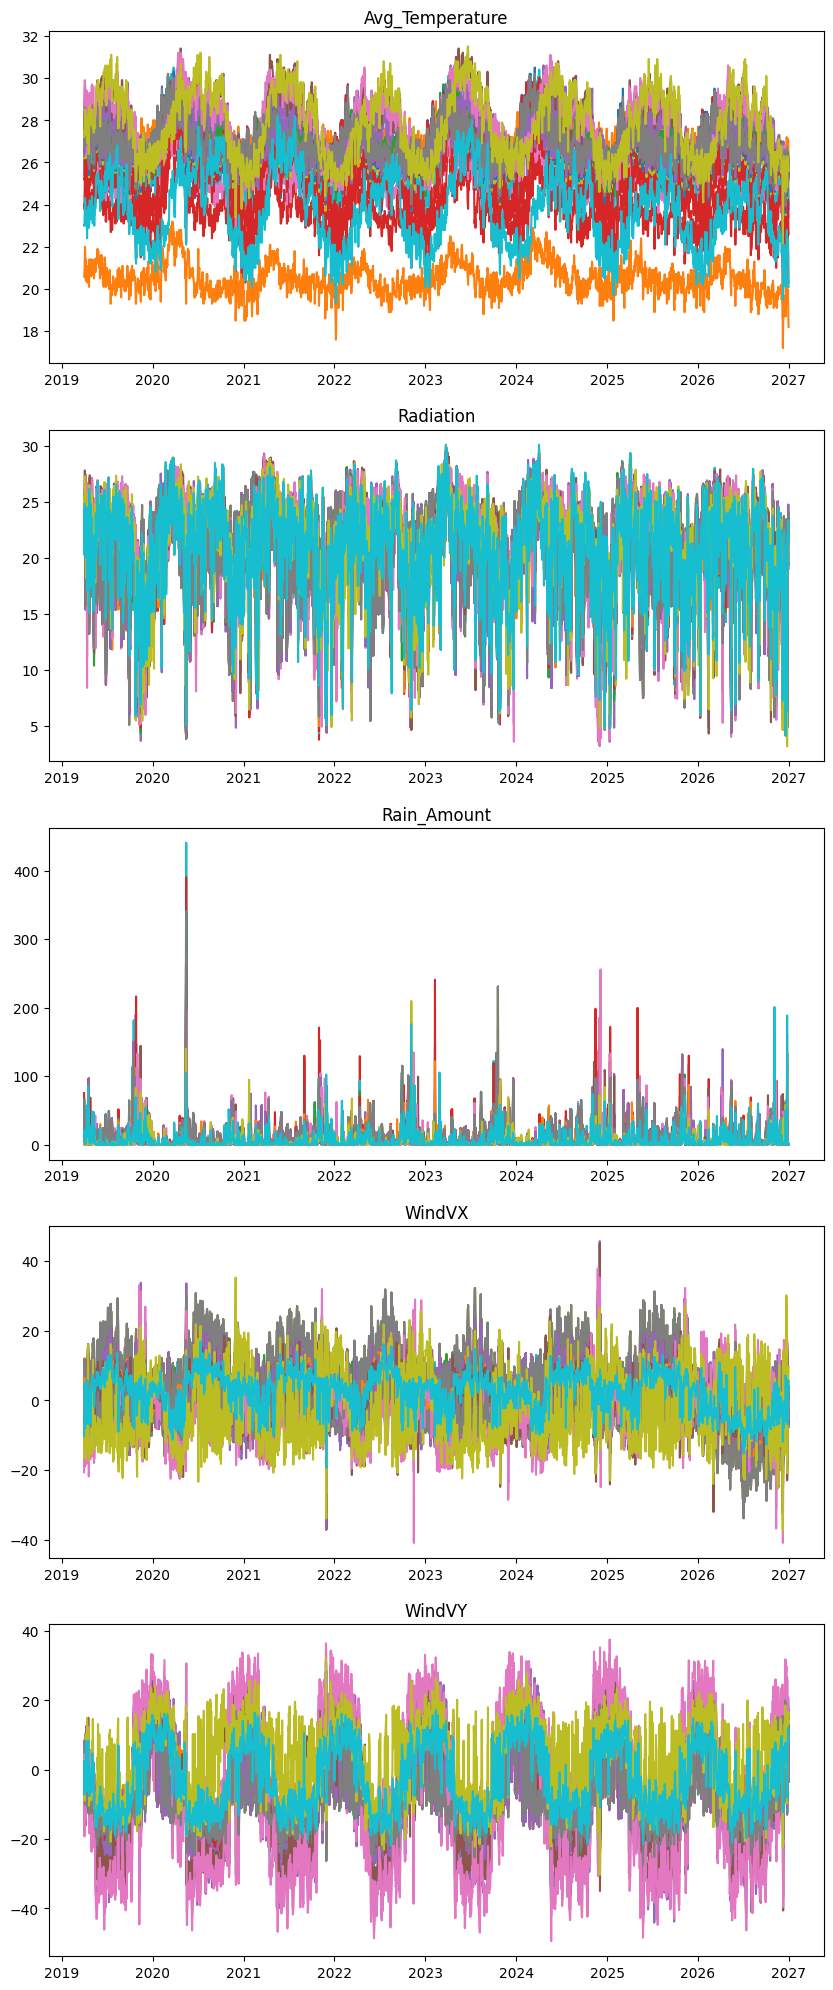

In [115]:
df_g = df_orig.drop(columns=['ID'] + cloc + cdate)
df_g.set_index("Date", inplace=True)

fig, ax = plt.subplots(len(ctarget), 1, figsize=(10, 5 * len(ctarget)))

for ci, col in enumerate(ctarget):
    plt.subplot(len(ctarget), 1, ci+1)
    for k in kingdoms:
        df_k = df_g[df_g['kingdom']==k]
        plt.plot(df_k.index, df_k[col], label=k)
        plt.title(col)
        # plt.legend()